In [ ]:
import os

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from datatree import open_datatree, DataTree
from var_assim.plotting.presets import get_presets

In [149]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [36]:
cwd = os.getcwd()
angles = ['10', '10']
filepath_base = cwd + '/../../model/data/output/pco2geowc/margobs_ws_angle'
filepath_end = '_ssp245_pco2geowc_TMIN2025_AR1_DEGpDEC0.1_NYRSRAMP50_Nwinds4_Nens500.nc'
dt_lo = open_datatree(filepath_base + '10' + filepath_end, engine='netcdf4')
dt_hi = open_datatree(filepath_base + '30' + filepath_end, engine='netcdf4')

In [40]:
dt_lo

DataTree('None', parent=None)
├── DataTree('2050')
│       Dimensions:         (ens_mem: 500, vari: 41, time: 26, iter: 101, obs_var: 4)
│       Coordinates:
│         * time            (time) float64 2.025e+03 2.026e+03 ... 2.049e+03 2.05e+03
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q23' 'q24' 'q25'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes:
│           tol:                       0.001
│           TMIN:                      2025
│           DT:                        1.0
│           TMAX:                      2050
│           ANGLE:                     10.009282007843852
│           run_time:                  179.45211029052734
│           internal_variability_std:  0.27
│           ECS:                       2.994918949966556
│           max_iter:                  100
├── DataTree('2075')
│       Dimensions:         (ens_mem: 500, vari: 66, time: 51, iter: 101, obs_var: 4)
│       Coordinates:
│         * time            (time) float64 2.025e+03 2.026e+03 ... 2.074e+03 2.075e+03
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q48' 'q49' 'q50'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes:
│           tol:                       0.001
│           TMIN:                      2025
│           DT:                        1.0
│           TMAX:                      2075
│           ANGLE:                     10.009282007843852
│           run_time:                  456.44835114479065
│           internal_variability_std:  0.27
│           ECS:                       2.994918949966556
│           max_iter:                  100
└── DataTree('2100')
        Dimensions:         (ens_mem: 500, vari: 91, time: 76, iter: 101, obs_var: 4)
        Coordinates:
          * time            (time) float64 2.025e+03 2.026e+03 ... 2.099e+03 2.1e+03
          * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
          * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q73' 'q74' 'q75'
          * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
          * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
        Data variables:
            data_final      (ens_me

In [90]:
def get_angle(a1, a2, b1, b2):
    angle = np.arccos(
        (a1 * b1 + a2 * b2) / np.sqrt(
            (a1**2 + a2**2) * (b1**2 + b2**2)
        )
    )
    return angle * (180 / np.pi)


In [91]:
tmp_a1 = dt_lo['2050'].ds.controls_hist.sel(vari='ALPHA_R1', iter=1).values
tmp_b1 = dt_lo['2050'].ds.controls_hist.sel(vari='BETA_R1', iter=1).values
tmp_a2 = dt_lo['2050'].ds.controls_hist.sel(vari='ALPHA_R2', iter=1).values
tmp_b2 = dt_lo['2050'].ds.controls_hist.sel(vari='BETA_R2', iter=1).values
angles_prior = get_angle(tmp_a1, tmp_a2, tmp_b1, tmp_b2)

In [92]:
angles_lo = np.zeros((len(dt_lo.children),
                      len(dt_lo['2050'].ds.ens_mem)))

assim_counter = 0
for assim in dt_lo.children:
    tmp_a1 = dt_lo[assim].ds.controls.sel(vari='ALPHA_R1').values
    tmp_b1 = dt_lo[assim].ds.controls.sel(vari='BETA_R1').values
    tmp_a2 = dt_lo[assim].ds.controls.sel(vari='ALPHA_R2').values
    tmp_b2 = dt_lo[assim].ds.controls.sel(vari='BETA_R2').values
    tmp_ang = get_angle(tmp_a1, tmp_a2, tmp_b1, tmp_b2)
    angles_lo[assim_counter] = tmp_ang

    assim_counter += 1

In [93]:
angles_hi = np.zeros((len(dt_lo.children),
                      len(dt_lo['2050'].ds.ens_mem)))

assim_counter = 0
for assim in dt_hi.children:
    tmp_a1 = dt_hi[assim].ds.controls.sel(vari='ALPHA_R1').values
    tmp_b1 = dt_hi[assim].ds.controls.sel(vari='BETA_R1').values
    tmp_a2 = dt_hi[assim].ds.controls.sel(vari='ALPHA_R2').values
    tmp_b2 = dt_hi[assim].ds.controls.sel(vari='BETA_R2').values
    tmp_ang = get_angle(tmp_a1, tmp_a2, tmp_b1, tmp_b2)
    angles_hi[assim_counter] = tmp_ang

    assim_counter += 1

/scratch/local/jobs/42287072/ipykernel_2896878/1014192424.py:4: RuntimeWarning: overflow encountered in multiply
  (a1**2 + a2**2) * (b1**2 + b2**2)


In [94]:
angles_plo = np.vstack([angles_prior, angles_lo])
angles_phi = np.vstack([angles_prior, angles_hi])
angles_lo_prog

array([[ 7.90341076, 20.27363687, 10.83539188, ..., 16.07457333,
         8.93506016, 11.52473044],
       [10.257973  , 11.18250189, 10.07136386, ..., 10.10827019,
         9.01302708, 10.08588733],
       [10.33010217, 10.27103471, 10.03726797, ..., 10.31874689,
        10.234345  , 10.42923791],
       [ 9.68163253, 10.00992346,  9.71857346, ..., 12.01883116,
        10.31805995, 10.53140073]])

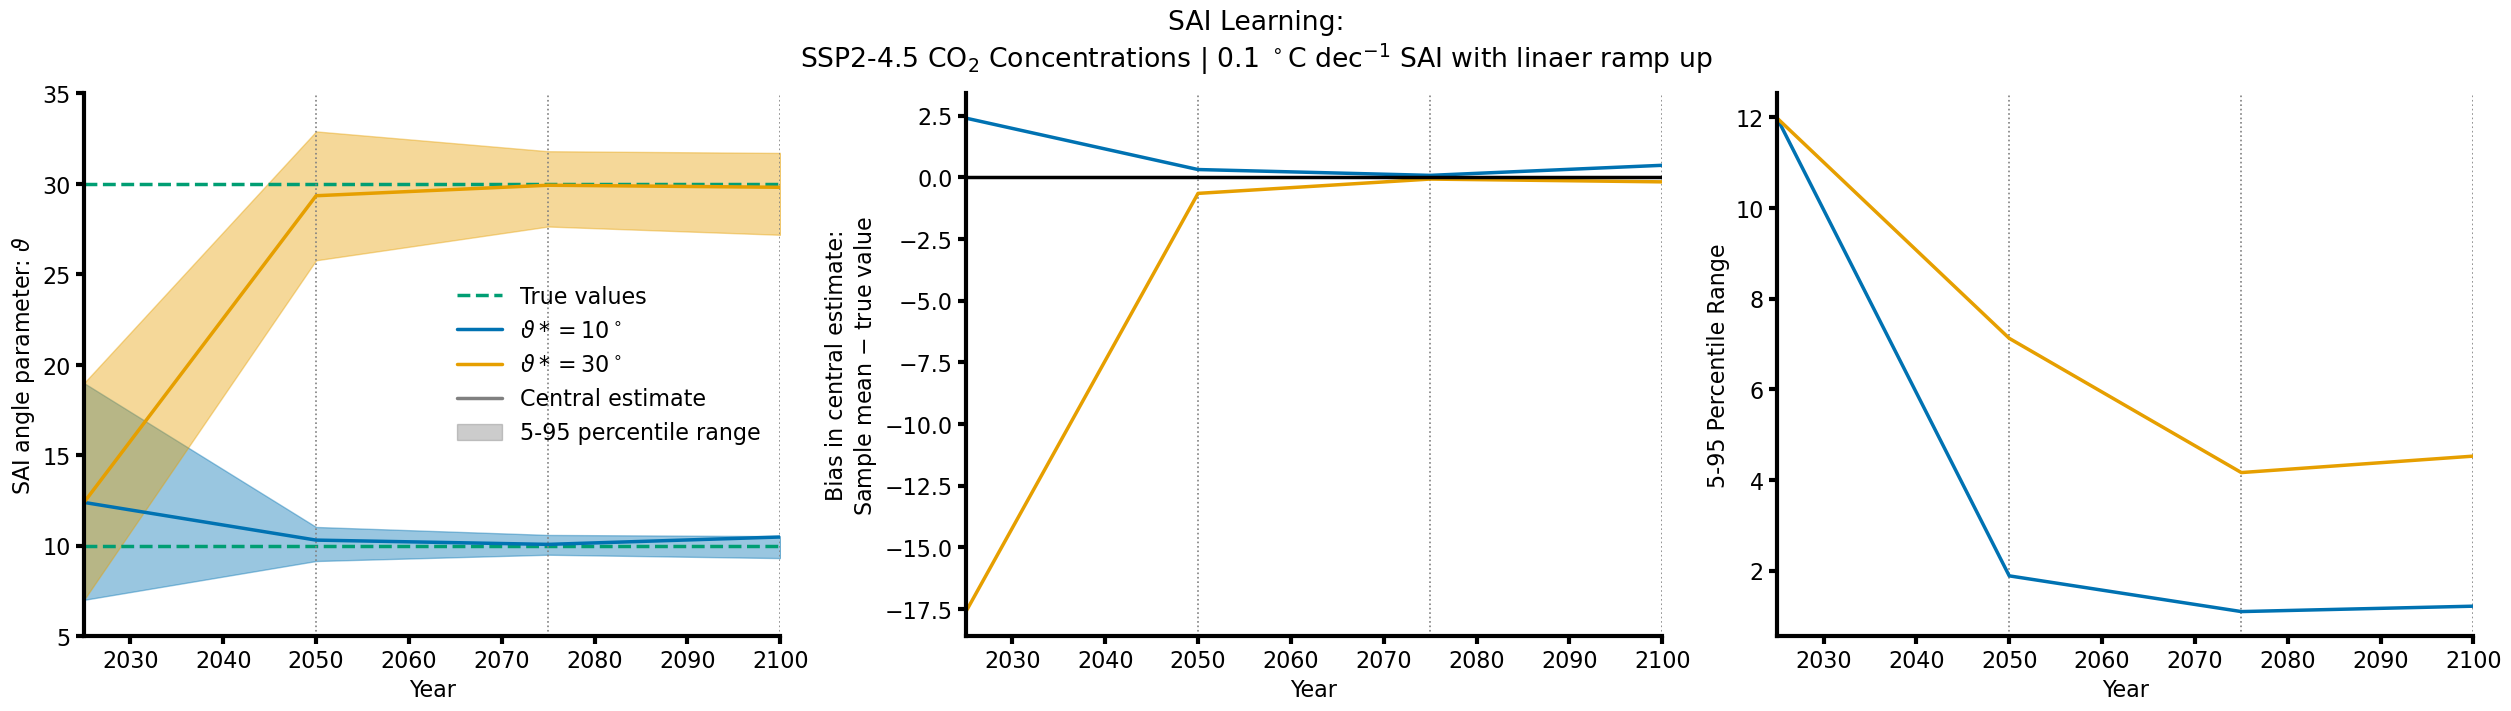

In [154]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
lo = 5
hi = 1
tr = 3

assim_times = np.array([2025, 2050, 2075, 2100])

fig, ax = plt.subplots(1, 3, figsize=(25, 7), layout='constrained')

ax[0].axhline(10, linestyle='dashed', color=colors[tr])
ax[0].axhline(30, linestyle='dashed', color=colors[tr], label='True values')

for i in range(3):
    ax[i].axvline(2050, linestyle='dotted', color='grey', linewidth=1.2)
    ax[i].axvline(2075, linestyle='dotted', color='grey', linewidth=1.2)
    ax[i].axvline(2100, linestyle='dotted', color='grey', linewidth=1.2)

ax[0].plot(assim_times, np.nanmean(angles_plo, axis=1), label=r'$\vartheta* = 10^\circ$', color=colors[lo])
ax[0].fill_between(assim_times,
                   np.percentile(angles_plo, 5, axis=1),
                   np.percentile(angles_plo, 95, axis=1),
                   alpha=0.4, color=colors[lo])

ax[0].plot(assim_times, np.nanmean(angles_phi, axis=1), linestyle='solid', label=r'$\vartheta* = 30^\circ$', color=colors[hi])
ax[0].fill_between(assim_times,
                   np.percentile(angles_phi, 5, axis=1),
                   np.percentile(angles_phi, 95, axis=1),
                   alpha=0.4, color=colors[hi])

ax[0].plot([-100, -100], [-100,-100], linestyle='solid', color='grey', label='Central estimate')
ax[0].fill_between([-100, -100], [-100,-100], [-100,-100], color='grey', label='5-95 percentile range', alpha=0.4)

ax[0].set_xlim((2025, 2100))
ax[0].set_ylim((5, 35))

ax[0].set_ylabel(r'SAI angle parameter: $\vartheta$')
ax[0].set_xlabel(r'Year')
ax[0].legend(facecolor='white')

ax[1].plot(assim_times, np.nanmean(angles_plo, axis=1) - 10., color=colors[lo])
ax[1].plot(assim_times, np.nanmean(angles_phi, axis=1) - 30., linestyle='solid', color=colors[hi])
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bias in central estimate:\nSample mean $-$ true value')
ax[1].axhline(0.0, color='black', linestyle='solid')
ax[1].set_xlim((2025, 2100))

ax[2].plot(assim_times, np.percentile(angles_plo, 95, axis=1) - np.percentile(angles_plo, 5, axis=1), color=colors[lo])
ax[2].plot(assim_times, np.percentile(angles_phi, 95, axis=1) - np.percentile(angles_phi, 5, axis=1), linestyle='solid', color=colors[hi])
ax[2].set_xlabel('Year')
ax[2].set_ylabel('5-95 Percentile Range')
ax[2].set_xlim((2025, 2100))

fig.suptitle('SAI Learning:\nSSP2-4.5 CO$_2$ Concentrations | 0.1 $^\circ$C dec$^{-1}$ SAI with linaer ramp up')
if SAVE_FIGS:
    filename = 'sai-learning-poc.png'
    fig.savefig(basefile + filename, dpi=400)